In [1]:
# ============================================================
#   Task 2: CNN Image Classification — Google Colab Version
#   Dataset : CIFAR-10 (60,000 public images, 10 classes)
#   Run on  : Runtime → Change runtime type → T4 GPU
# ============================================================

# ── 1: Mount Google Drive ───────────────────────────────
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# ── 2: Imports ─────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import seaborn as sns

print("TensorFlow version :", tf.__version__)
print("GPU available       :", tf.config.list_physical_devices('GPU'))


TensorFlow version : 2.19.0
GPU available       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
  Train : (50000, 32, 32, 3)
  Test  : (10000, 32, 32, 3)

Pixel range after normalisation: [0.0, 1.0]


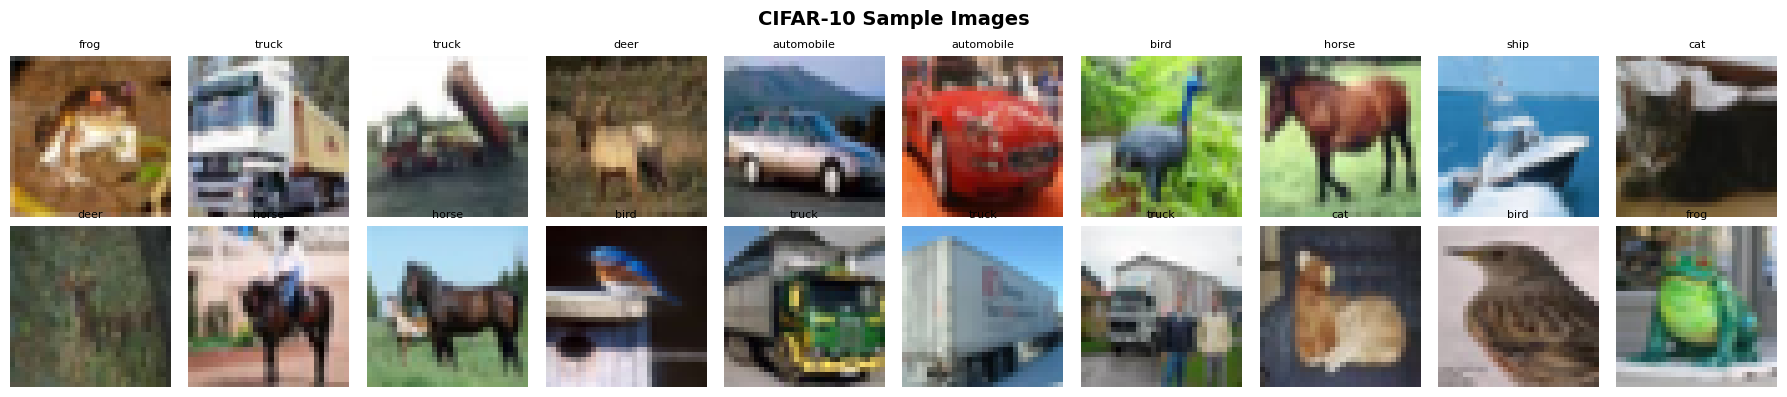

In [3]:
# ── 3: Load & Preprocess CIFAR-10 ──────────────────────
CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("\nLoading CIFAR-10 dataset...")
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(f"  Train : {X_train.shape}")
print(f"  Test  : {X_test.shape}")

# --- Preprocessing: Normalise pixel values to [0, 1] ---------
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# --- One-hot encode labels -----------------------------------
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

print(f"\nPixel range after normalisation: [{X_train.min():.1f}, {X_train.max():.1f}]")

# --- Preview sample images -----------------------------------
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('CIFAR-10 Sample Images', fontsize=14, fontweight='bold')
for i in range(20):
    ax = axes[i // 10][i % 10]
    ax.imshow(X_train[i])
    ax.set_title(CLASS_NAMES[y_train[i][0]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [4]:
# ── 4: Build CNN Architecture ──────────────────────────
def build_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential(name="CNN_CIFAR10")

    # ── Block 1: Convolution + Pooling ────────────────────
    model.add(layers.Conv2D(32, (3,3), activation='relu',
                            padding='same', input_shape=input_shape,
                            name='conv1'))                  # Convolution layer
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu',
                            padding='same', name='conv2'))  # Convolution layer
    model.add(layers.MaxPooling2D((2,2), name='pool1'))     # Pooling layer
    model.add(layers.Dropout(0.25))

    # ── Block 2: Convolution + Pooling ────────────────────
    model.add(layers.Conv2D(64, (3,3), activation='relu',
                            padding='same', name='conv3'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu',
                            padding='same', name='conv4'))
    model.add(layers.MaxPooling2D((2,2), name='pool2'))
    model.add(layers.Dropout(0.25))

    # ── Block 3: Convolution + Pooling ────────────────────
    model.add(layers.Conv2D(128, (3,3), activation='relu',
                            padding='same', name='conv5'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2), name='pool3'))
    model.add(layers.Dropout(0.25))

    # ── Fully Connected Layers ────────────────────────────
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(256, activation='relu', name='fc1'))   # FC layer
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(128, activation='relu', name='fc2'))   # FC layer
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation='softmax',
                           name='output'))                         # Output layer
    return model

model = build_cnn()
model.summary()

Model: "CNN_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 700,074 (2.67 MB)

 Trainable params: 699,114 (2.67 MB)

 Non-trainable params: 960 (3.75 KB)

In [5]:
# ── 5: Compile & Train ──────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/best_cnn_cifar10.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\nTraining CNN (up to 50 epochs with early stopping)...")
print("GPU will make this ~10x faster than CPU.\n")

history = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)


Training CNN (up to 50 epochs with early stopping)...
GPU will make this ~10x faster than CPU.

Epoch 1/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2881 - loss: 2.1613
Epoch 1: val_accuracy improved from None to 0.43800, saving model to /content/drive/MyDrive/best_cnn_cifar10.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_cnn_cifar10.keras
665/665 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.3667 - loss: 1.8021 - val_accuracy: 0.4380 - val_loss: 1.6337 - learning_rate: 0.0010
Epoch 2/50
662/665 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4925 - loss: 1.3934
Epoch 2: val_accuracy did not improve from 0.43800
665/665 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5231 - loss: 1.3141 - val_accuracy: 0.4239 - val_loss: 1.9582 - learning_rate: 0.0010
Epoch 3/50
663/665 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5914 - loss: 1.1332
Epoch 3: val_accuracy improved from 0.43800 to 0.63520, saving model to /content/drive/MyDrive/best_cnn_cifar10.k

In [6]:
# ── 6: Evaluate on Test Set ────────────────────────────
print("\nEvaluating on test set...")
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test.flatten()

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\n" + "="*55)
print("  EVALUATION METRICS (Weighted Average)")
print("="*55)
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print("="*55)

print("\nPer-Class Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))



Evaluating on test set...

  EVALUATION METRICS (Weighted Average)
  Accuracy  : 85.92%
  Precision : 85.92%
  Recall    : 85.92%
  F1-Score  : 85.81%

Per-Class Report:
              precision    recall  f1-score   support

    airplane       0.86      0.88      0.87      1000
  automobile       0.94      0.92      0.93      1000
        bird       0.86      0.75      0.80      1000
         cat       0.77      0.68      0.72      1000
        deer       0.81      0.87      0.84      1000
         dog       0.78      0.82      0.80      1000
        frog       0.85      0.91      0.88      1000
       horse       0.91      0.89      0.90      1000
        ship       0.90      0.94      0.92      1000
       truck       0.91      0.92      0.92      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [7]:
# ── 7: Metric Explanations ──────────────────────────────
print("\n" + "="*55)
print("  METRIC EXPLANATIONS")
print("="*55)

metrics_info = {
    "Accuracy": (
        "Proportion of ALL predictions that are correct.\n"
        "  Formula : (TP + TN) / (TP + TN + FP + FN)\n"
        "  Tells us: Overall correctness across all classes.\n"
        "  Caveat  : Misleading on imbalanced datasets."
    ),
    "Precision": (
        "Of all images predicted as class X, how many truly are X?\n"
        "  Formula : TP / (TP + FP)\n"
        "  Tells us: Reliability of positive predictions (fewer false alarms)."
    ),
    "Recall": (
        "Of all true class-X images, how many did the model find?\n"
        "  Formula : TP / (TP + FN)\n"
        "  Tells us: Ability to detect all true positives (sensitivity)."
    ),
    "F1-Score": (
        "Harmonic mean of Precision and Recall.\n"
        "  Formula : 2 x (Precision x Recall) / (Precision + Recall)\n"
        "  Tells us: Balanced measure when precision and recall trade off."
    ),
}
for name, info in metrics_info.items():
    print(f"\n{name}:\n  {info}")



  METRIC EXPLANATIONS

Accuracy:
  Proportion of ALL predictions that are correct.
  Formula : (TP + TN) / (TP + TN + FP + FN)
  Tells us: Overall correctness across all classes.
  Caveat  : Misleading on imbalanced datasets.

Precision:
  Of all images predicted as class X, how many truly are X?
  Formula : TP / (TP + FP)
  Tells us: Reliability of positive predictions (fewer false alarms).

Recall:
  Of all true class-X images, how many did the model find?
  Formula : TP / (TP + FN)
  Tells us: Ability to detect all true positives (sensitivity).

F1-Score:
  Harmonic mean of Precision and Recall.
  Formula : 2 x (Precision x Recall) / (Precision + Recall)
  Tells us: Balanced measure when precision and recall trade off.


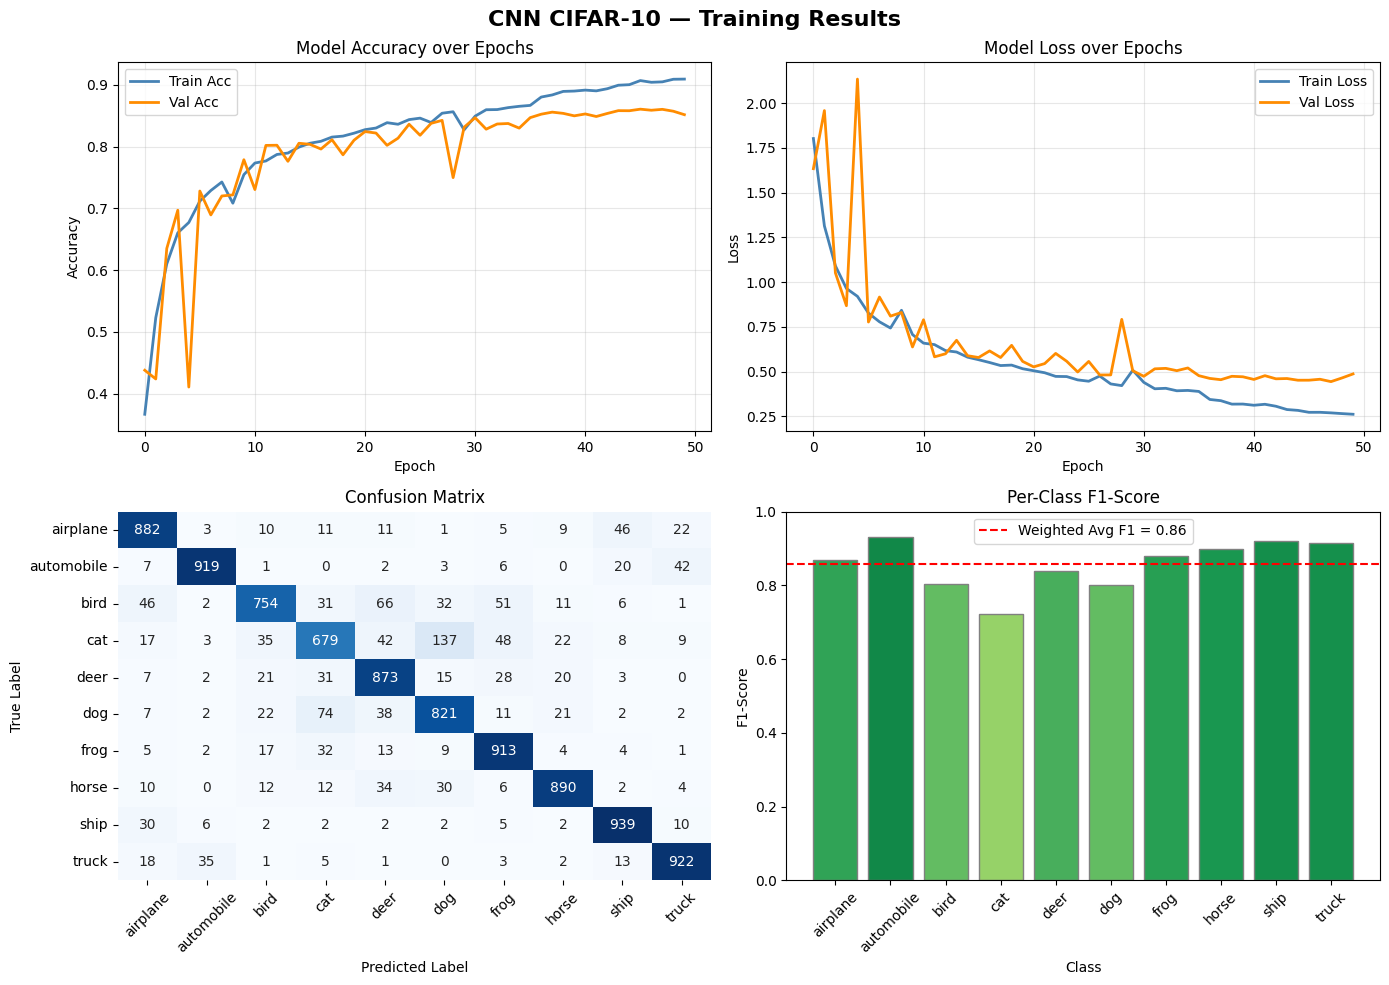


Plot saved to Google Drive.


In [8]:
# ── 8: Visualisations ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CNN CIFAR-10 — Training Results', fontsize=16, fontweight='bold')

# (a) Accuracy curves
ax = axes[0, 0]
ax.plot(history.history['accuracy'],     label='Train Acc',  color='steelblue',  linewidth=2)
ax.plot(history.history['val_accuracy'], label='Val Acc',    color='darkorange', linewidth=2)
ax.set_title('Model Accuracy over Epochs')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

# (b) Loss curves
ax = axes[0, 1]
ax.plot(history.history['loss'],     label='Train Loss', color='steelblue',  linewidth=2)
ax.plot(history.history['val_loss'], label='Val Loss',   color='darkorange', linewidth=2)
ax.set_title('Model Loss over Epochs')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# (c) Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1, 0], cbar=False)
axes[1, 0].set_title('Confusion Matrix')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].tick_params(axis='x', rotation=45)

# (d) Per-class F1-Score bar chart
per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
bar_colors   = plt.cm.RdYlGn(per_class_f1)
axes[1, 1].bar(CLASS_NAMES, per_class_f1, color=bar_colors, edgecolor='grey')
axes[1, 1].set_title('Per-Class F1-Score')
axes[1, 1].set_xlabel('Class'); axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].axhline(y=f1, color='red', linestyle='--', linewidth=1.5,
                   label=f'Weighted Avg F1 = {f1:.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cnn_cifar10_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to Google Drive.")



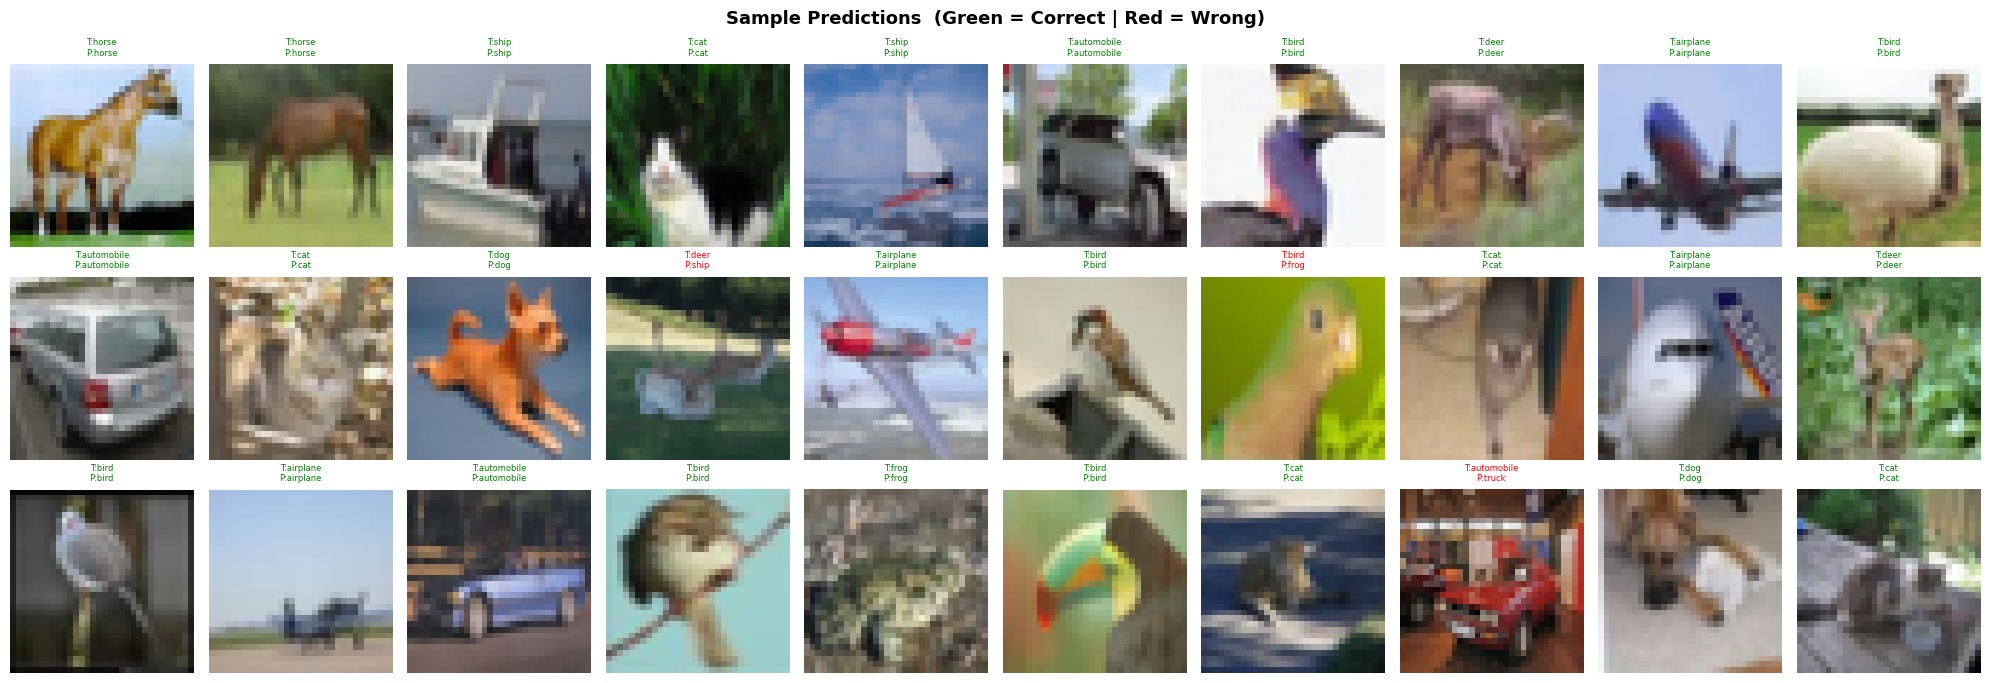

In [9]:
# ── 9: Show Sample Predictions ─────────────────────────
fig, axes = plt.subplots(3, 10, figsize=(20, 7))
fig.suptitle('Sample Predictions  (Green = Correct | Red = Wrong)',
             fontsize=13, fontweight='bold')

indices = np.random.choice(len(X_test), 30, replace=False)
for i, idx in enumerate(indices):
    ax   = axes[i // 10][i % 10]
    true = CLASS_NAMES[y_true[idx]]
    pred = CLASS_NAMES[y_pred[idx]]
    ax.imshow(X_test[idx])
    color = 'green' if true == pred else 'red'
    ax.set_title(f"T:{true}\nP:{pred}", fontsize=6, color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cnn_cifar10_predictions.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# ── 10: Save Final Model ────────────────────────────────
model.save('/content/drive/MyDrive/cnn_cifar10_final.keras')
print("\nModel saved to Google Drive as 'cnn_cifar10_final.keras'")
print("\n✅ Task 2 Complete!")
print(f"   Final Test Accuracy : {accuracy*100:.2f}%")
print(f"   Final F1-Score      : {f1*100:.2f}%")


Model saved to Google Drive as 'cnn_cifar10_final.keras'

✅ Task 2 Complete!
   Final Test Accuracy : 85.92%
   Final F1-Score      : 85.81%
